In [30]:
import tensorflow as tf
import numpy as np

# Load MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Parameters
num_classes = 10
input_shape = (28, 28, 1)  # Grayscale MNIST

def preprocess(images, shape):
    # Convert to float32 and expand channel dimension
    images = tf.expand_dims(images, axis=-1)
    # Resize (optional here, MNIST is already 28x28)
    images = tf.image.resize(images, shape[:2])
    # Normalize to [0,1]
    images = images / 255.0
    return images

train_images = preprocess(train_images, input_shape)
test_images = preprocess(test_images, input_shape)

# One-hot encode labels
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes)

print("Train shape:", train_images.shape)  # (60000, 28, 28, 1)
print("Test shape:", test_images.shape)    # (10000, 28, 28, 1)


Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [31]:
import tensorflow as tf

def tiny_mbconv_block(x, expansion_factor, filters, name):
    input_channels = x.shape[-1]
    
    # 1. Expansion (skip for expansion_factor=1)
    if expansion_factor != 1:
        y = tf.keras.layers.Conv2D(input_channels * expansion_factor, 1, padding="same", use_bias=False, name=f"{name}_expand")(x)
        y = tf.keras.layers.BatchNormalization(name=f"{name}_bn1")(y)
        y = tf.keras.layers.Activation("swish", name=f"{name}_swish1")(y)
    else:
        y = x
    
    # 2. Depthwise conv
    y = tf.keras.layers.DepthwiseConv2D(3, padding="same", use_bias=False, name=f"{name}_dwconv")(y)
    y = tf.keras.layers.BatchNormalization(name=f"{name}_bn2")(y)
    y = tf.keras.layers.Activation("swish", name=f"{name}_swish2")(y)
    
    # 3. Output projection
    y = tf.keras.layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_project")(y)
    y = tf.keras.layers.BatchNormalization(name=f"{name}_bn3")(y)
    
    # 4. Residual connection
    if input_channels == filters:
        y = tf.keras.layers.Add(name=f"{name}_add")([x, y])
    
    return y

def build_ultra_tiny_efficientnet(input_shape=(28,28,1), classes=10):
    model_input = tf.keras.layers.Input(shape=input_shape)
    
    # Initial Conv
    x = tf.keras.layers.Conv2D(16, 3, strides=1, padding="same", use_bias=False)(model_input)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("swish")(x)
    
    # Tiny MBConv blocks
    x = tiny_mbconv_block(x, expansion_factor=1, filters=16, name="block1")
    x = tiny_mbconv_block(x, expansion_factor=1, filters=16, name="block2")
    
    # Final Conv (reduce channels)
    x = tf.keras.layers.Conv2D(64, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("swish")(x)
    
    # Global pooling + classifier
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    model_output = tf.keras.layers.Dense(classes, activation="softmax")(x)
    
    return tf.keras.Model(inputs=model_input, outputs=model_output)

# Build and summarize
model = build_ultra_tiny_efficientnet()
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │        144 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         64 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_dwconv       │ (None, 28, 28,    │        144 │ activation_6[0][… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 28, 28,    │         64 │ block1_dwconv[0]… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_swish2       │ (None, 28, 28,    │          0 │ block1_bn2[0][0]  │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_project      │ (None, 28, 28,    │        256 │ block1_swish2[0]… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn3          │ (None, 28, 28,    │         64 │ block1_project[0… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 28, 28,    │          0 │ activation_6[0][… │
│                     │ 16)               │            │ block1_bn3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_dwconv       │ (None, 28, 28,    │        144 │ block1_add[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn2          │ (None, 28, 28,    │         64 │ block2_dwconv[0]… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_swish2       │ (None, 28, 28,    │          0 │ block2_bn2[0][0]  │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_project      │ (None, 28, 28,    │        256 │ block2_swish2[0]… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn3          │ (None, 28, 28,    │         64 │ block2_project[0… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_add (Add)    │ (None, 28, 28,    │          0 │ block1_add[0][0], │
│                     │ 16)               │            │ block2_bn3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │      1,024 │ block2_add[0][0]

 Total params: 3,194 (12.48 KB)

 Trainable params: 2,906 (11.35 KB)

 Non-trainable params: 288 (1.12 KB)

In [32]:
# Compile the model
model.compile(loss='categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, 
                    batch_size=128, 
                    epochs=10, 
                    validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.4970 - loss: 1.5771 - val_accuracy: 0.1045 - val_loss: 8.0769
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 180ms/step - accuracy: 0.7769 - loss: 0.8414 - val_accuracy: 0.6262 - val_loss: 1.0320
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 185ms/step - accuracy: 0.8841 - loss: 0.5043 - val_accuracy: 0.6852 - val_loss: 0.9004
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 180ms/step - accuracy: 0.9131 - loss: 0.3598 - val_accuracy: 0.6667 - val_loss: 0.9413
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 75s 179ms/step - accuracy: 0.9264 - loss: 0.2934 - val_accuracy: 0.8698 - val_loss: 0.4194
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 183ms/step - accuracy: 0.9352 - loss: 0.2519 - val_accuracy: 0.9367 - val_loss: 0.2353
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 179ms/step - accuracy: 0.9406 - loss: 0.2258 - val_accuracy: 0.9458 - val_loss: 0.1933
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 179ms/step - accuracy: 0.9457 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Batch Test Accuracy: 94.19%


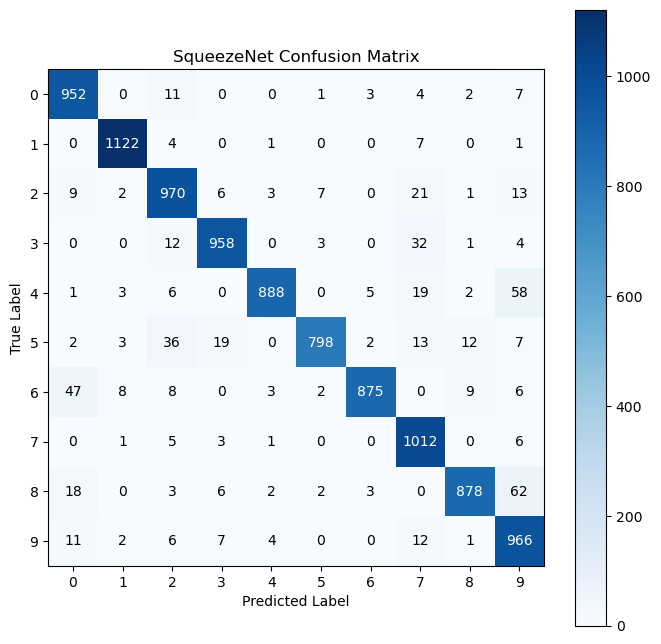

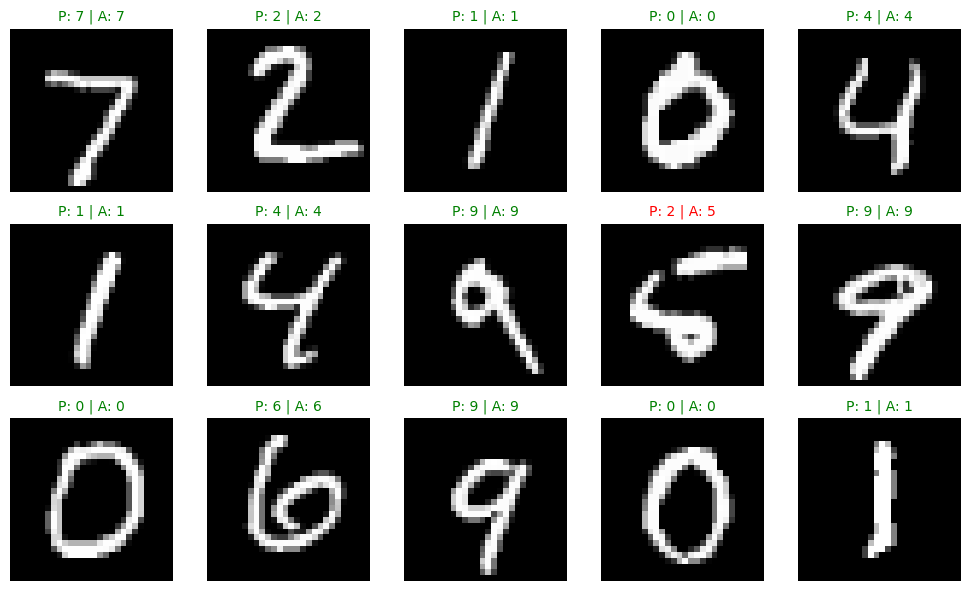

In [39]:
# 1. Get predictions for the entire test set
batch_predictions = model.predict(test_images)
y_pred = np.argmax(batch_predictions, axis=1)
y_true = np.argmax(test_labels, axis=1)

# 2. Calculate accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Batch Test Accuracy: {accuracy * 100:.2f}%")
# 3. Create Confusion Matrix manually
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

# 4. Plot using Matplotlib
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Add labels to the axes
ax.set(xticks=np.arange(num_classes),
       yticks=np.arange(num_classes),
       xticklabels=range(num_classes), 
       yticklabels=range(num_classes),
       title='SqueezeNet Confusion Matrix',
       ylabel='True Label',
       xlabel='Predicted Label')

# Annotate each cell with the numeric value
thresh = cm.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()
# 5. Visualize first 15 results
plt.figure(figsize=(10, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(test_images[i][:,:,0], cmap='gray')
    
    color = 'green' if y_pred[i] == y_true[i] else 'red'
    plt.title(f"P: {y_pred[i]} | A: {y_true[i]}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [40]:
# Assuming your model variable is named 'model'
model.save('efficientnet_model.h5')

print("Model saved successfully as efficientnet_model.h5")

Model saved successfully as efficientnet_model.h5


In [41]:
import tensorflow as tf
import numpy as np

# 1. Load Keras model (already trained for MNIST)
model = tf.keras.models.load_model('efficientnet_model.h5')

# 2. Load MNIST dataset
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0  # normalize to [0,1]

# 3. Preprocess images for 28x28x1
def preprocess_image(img):
    # Add channel dimension (28x28 -> 28x28x1)
    img = np.expand_dims(img, axis=-1)
    return img

x_train_28 = np.array([preprocess_image(img) for img in x_train[:100]])  # first 100 for representative dataset

# 4. Representative dataset generator for INT8 quantization
def representative_data_gen():
    for input_value in x_train_28:
        # Add batch dimension (1, 28, 28, 1)
        yield [np.expand_dims(input_value, axis=0)]

# 5. Setup TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 6. Convert to TFLite
tflite_model = converter.convert()

# 7. Save TFLite model
TFLITE_MODEL_PATH = 'efficientnet_model.tflite'
with open(TFLITE_MODEL_PATH, 'wb') as f:
    f.write(tflite_model)

print("Quantization Successful! Model saved at:", TFLITE_MODEL_PATH)


INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmpdhqit14h\assets


INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmpdhqit14h\assets


Saved artifact at 'C:\Users\ng822\AppData\Local\Temp\tmpdhqit14h'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2055697253200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2055697259344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2055697262416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2055697260496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2055697262800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058834279696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058834098320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058834091792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058835280912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058835293200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  20588

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantization Successful! Model saved at: efficientnet_model.tflite


In [42]:
import os

def convert_tflite2cc(tflite_path, cc_path, model_name="efficientnet_model"):
    """Converts a TFLite file to a C++ file containing a byte array."""
    with open(tflite_path, 'rb') as f:
        tflite_content = f.read()
    
    hex_line = [f'0x{byte:02x}' for byte in tflite_content]
    
    with open(cc_path, 'w') as f:
        f.write(f'#include "{model_name}.h"\n\n')
        f.write(f'const unsigned char g_{model_name}_data[] = {{\n')
        # Write 12 hex values per line for readability
        for i in range(0, len(hex_line), 12):
            f.write('  ' + ', '.join(hex_line[i:i+12]) + ',\n')
        f.write(f'}};\n\n')
        f.write(f'const int g_{model_name}_data_len = {len(tflite_content)};\n')

# Generate the .cc file
convert_tflite2cc(TFLITE_MODEL_PATH, "efficientnet_model.cc")

In [43]:
def generate_h_file(h_path, model_name="efficientnet_model"):
    with open(h_path, 'w') as f:
        f.write(f'#ifndef {model_name.upper()}_DATA_H_\n')
        f.write(f'#define {model_name.upper()}_DATA_H_\n\n')
        f.write(f'extern const unsigned char g_{model_name}_data[];\n')
        f.write(f'extern const int g_{model_name}_data_len;\n\n')
        f.write(f'#endif // {model_name.upper()}_DATA_H_\n')

# Generate the .h file
generate_h_file("efficientnet_model.h")

In [44]:
interpreter = tf.lite.Interpreter(model_path="efficientnet_model.tflite")
interpreter.allocate_tensors()

print("=== Tensors ===")
for t in interpreter.get_tensor_details():
    print(
        f"name={t['name']}, "
        f"shape={t['shape']}, "
        f"dtype={t['dtype']}"
    )

print("\n=== Ops ===")
for op in interpreter._get_ops_details():
    print(op["op_name"])


=== Tensors ===
name=serving_default_input_layer_3:0, shape=[ 1 28 28  1], dtype=<class 'numpy.int8'>
name=arith.constant, shape=[2], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst, shape=[10], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst1, shape=[10 64], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst2, shape=[64], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst3, shape=[64  1  1 16], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst4, shape=[16], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst5, shape=[16  1  1 16], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst6, shape=[16], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst7, shape=[ 1  3  3 16], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst8, shape=[16], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst9, shape=[16  1  1 16], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst10, shape=[16], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst11, shape=[ 1  3  3 16], dtype=<class 'numpy.int8'>
name=tfl.pseudo

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
